# Auxiliar 1: Uso de la distribucion gaussiana en experimentos aleatorios.

Por: Javiera Toro Grey - Otoño 2025

# Conceptos clave

## Variable Aleatoria

Es el observable que "nace" desde una distribución de probabilidad. Si hacemos el experimento varias veces, este observable cambiará pero solo dentro de los límites puestos por su distribucion padre.


Ejemplo:
Claudia quiere estudiar que numeros entrega un dado luego de lanzarlo. Podemos imaginar la distribucion "padre" como una caja de bolitas con números del 1 al 6; así cada vez que Claudia lanza el dado (saca una bolita de la distribución padre) el resultado cambiará.

Pero no se puede obtener un numero 7, porque la distribucion padre nos da los limites permitidos para el dado (solo hay 6 bolitas). Con esto, el número que se obtiene al lanzar un dado es una variable aleatoria.


## Distribución Normal o Gaussiana,  $\mathcal{N}(\mu, \sigma^2)$

Sea $X$ una variable aleatoria, con $\mu$ el promedio y $\sigma^2$ la varianza. $X$ 

Así $\mathcal{N}(\mu, \sigma^2)$ esta definida como $f(x)$:

$$ f(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left(\frac{-(x-\mu)^2}{2\sigma^2}\right) $$

Esta es la cajita de la cual vamos a obtener los posibles valores del experimento ($X$), o alguna caracteristica de los datos (promedio). Esta es la distribución padre.

## Idea principal del método de Monte Carlo

El método de Monte Carlo se basa en obtener un resultado estadístico robusto a partir de múltiples simulaciones. La clave es generar múltiples conjuntos de datos sintéticos a partir de la distribución padre de los datos observados y usarlos para inferir propiedades intrínsecas del sistema.

¿-Por qué usar Monte Carlo?

En muchas situaciones, los datos observados contienen incertidumbre asociadas, y los métodos analíticos no siempre permiten una estimación precisa. Monte Carlo nos permite:
- Propagar la incertidumbre de manera efectiva.
- Estimar distribuciones de probabilidades cuando las ecuaciones son complejas.
- Obtener intervalos de confianza en experimentos ruidosos.


Así uno puede seguir estos pasos para el método de Monte Carlo

1.-Definir el problema → Partimos de datos experimentales con incertidumbre.

2.- Inferir la distribución padre → Estimamos qué tipo de distribución sigue la variable (ej. normal, log-normal, Poisson, etc.).

3.- Generar múltiples simulaciones → Creamos muestras aleatorias basadas en la distribución padre.

4.- Calcular la característica de interés → Por cada simulación, estimamos el parámetro que buscamos (ej. media, dispersión, masa estelar, etc.).

5.- Obtener intervalos de confianza → Analizamos la distribución de los resultados para determinar un intervalo de confianza, asegurando que la estimación es robusta.

Recordar que aqui podemos utilizar BOOTSTRAP :)

# Ejercicio

Un grupo de astronomos ha etsado observando una estrella y ha obtenido multiples mediciones de su temperatura superficial. Dada las incertezas observacionales, cada medicion tiene un error asociado.

Ahora, quieren estimar la masa estelar basada en las mediciones de temperatura. Dada que la relación masa-temperatura sigue:

$$M \alpha \frac{1}{T^{2}}$$
Necesitan de tu ayuda para determinar la masa de la estrella a un intervalo de confianza del 95%.




### PRIMERO VISUALICEMOS LOS DATOS OBTENIDOS

Primero leemos los datos de temperatura del archivo 'temperaturas.csv'

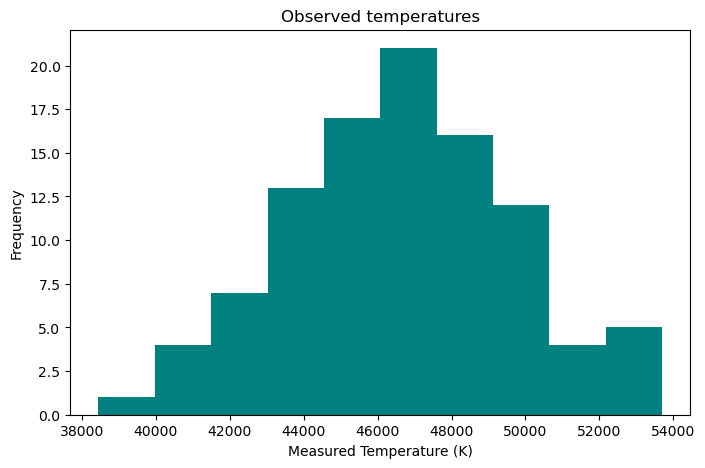

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd

# Mediciones de temperatura en Kelvin
np.random.seed(0)  # Mantenemos la misma semilla para replicar el resultado

obs_tem = pd.read_csv('temperaturas.csv')['temp [K]']
N_sample = len(obs_tem)

# Plot histograma
plt.figure(figsize=(8, 5))
plt.hist(obs_tem, color='teal')
plt.xlabel("Measured Temperature (K)")
plt.ylabel("Frequency")
plt.title('Observed temperatures')
plt.show()



### Ahora queremos revisar la distribucion padre:

Podemos asumir que la temperatura sigue una distribucion normal, revisemos

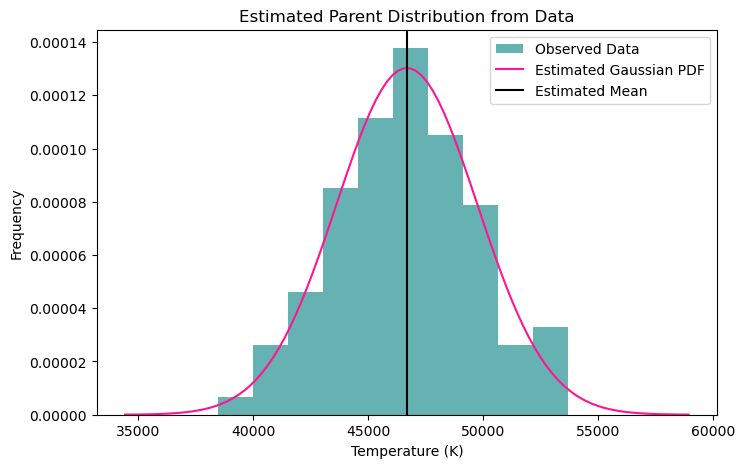

In [24]:
# Estimamos los parametros de la muestra
mean_est = np.mean(obs_tem)
std_est = np.std(obs_tem, ddof=1)

# Creamos la distribucion padre y sus samples
dist_padre = norm(loc=mean_est, scale=std_est)

# Ploteamos distribucion padre
x_vals = np.linspace(mean_est - 4 * std_est, mean_est + 4 * std_est, 100)
plt.figure(figsize=(8, 5))
plt.hist(obs_tem, color='teal', alpha=0.6, label="Observed Data", density=True)
plt.plot(x_vals, dist_padre.pdf(x_vals), label='Estimated Gaussian PDF', color='deeppink')
plt.axvline(mean_est, color='black', linestyle="-", label="Estimated Mean")
plt.xlabel("Temperature (K)")
plt.ylabel("Frequency")
plt.title("Estimated Parent Distribution from Data")
plt.legend()
plt.show()

### ¿Podemos asumir entonces que la masa también sigue una distribucion normal?

No podemos! Esto es porque la relación masa-temperatura no es lineal, lo que no permite esa transferencia. En caso de que la relación fuese lineal, si podemos asumir que la masa tambien tiene una distribucion normal con $\mu$ y $\sigma$ conocidos desde T.

Entonces, ¿Qué hacemos?

Aquí es donde el método de MC se vuelve util, que nos ayuda a la propagacion de los errores y, además, en la estimación de la masa manteniendo adjustandose estadísticamente. También usamos Bootstrap :)

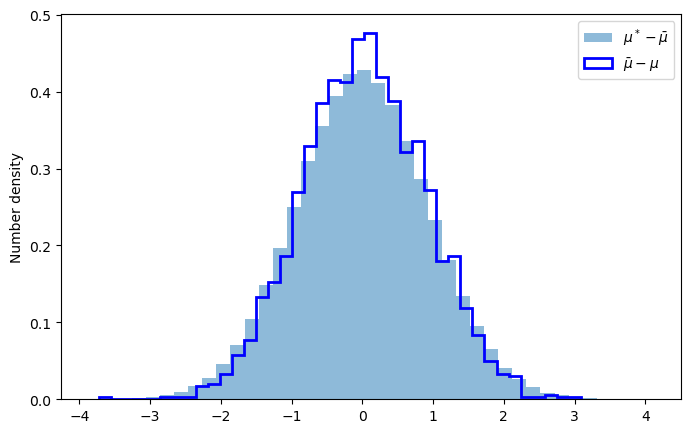

In [48]:
# Creamos funcion para la relación M-T

def temp_to_mass(T):
    '''
    Recibe la temperatura de una estrella y retorna su
    la masa estelar.
    INPUT:
     - t : Temperatura de la estrella en Kelvin
    OUTPUT:
     - m : Masa de la estrella en Masas solares
    '''
    t_sun = 5800 # Para trabajar en M_sun
    return (T / t_sun)**2 

# Con esto realizamos la simulacion varias vecesobtengamos varios samples de la temperatura

# Obtenemos la medicion de masa de las temperaturas observadas
mu = np.mean(temp_to_mass(obs_tem))

# Creamos nuevos samples y sus respectivas masas
N_repetitions = int(np.round(N_sample * (np.log(N_sample))**2))

base_temp = dist_padre.rvs(size=N_sample)  # Sample base
samp_temp = dist_padre.rvs(size=(N_sample, N_repetitions))  # Sample de temperaturas

base_mass = temp_to_mass(base_temp) # Sample base
mu_bar = np.mean(base_mass)  # masa promedio sample base
samp_mass = temp_to_mass(samp_temp) # Sample de masas
mu_samp = np.mean(samp_mass, axis=0)  # masa promedio de todos los samples

bootstrap_means = []
N_boot = 100*N_repetitions

# Repetimos muchas veces el experimento
for i in range(N_boot):
    indices = np.random.randint(0, high=N_sample, size=N_sample)
    mean_of_sample = np.mean(base_mass[indices])
    bootstrap_means.append(mean_of_sample)
    
bootstrap_means = np.array(bootstrap_means)

plt.figure(figsize=(8, 5))
plt.hist(bootstrap_means - mu_bar, 
         bins=40, density=True, alpha=0.5, label=r'$\mu^*-\bar{\mu}$')

plt.hist(mu_samp-mu, bins=40, density=True, histtype='step', 
         color='blue', lw=2, label=r'$\bar{\mu}-\mu$')

plt.ylabel('Number density')
_= plt.legend()

### Ahora buscamos el intervalo de confianza al 95%

In [47]:
percentage = 0.95
alpha = 1 - percentage

interval = np.percentile(bootstrap_means-mu_bar, [alpha/2*100, (1-alpha/2)*100])

print('El intervalo de confianza al 95% de la masa es [{:.2f}: {:.2f}]'.format(*(mu_bar+interval)))

El intervalo de confianza al 95% de la masa es [64.39: 67.72]


### Con esto podemos estimar que la masa de la estrella con un 95% de confianza está entre 64 y 68 masas solares